In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [3]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing values:\n", sentiment.isnull().sum())
print("\nMissing values:\n", trades.isnull().sum())

print("\nDuplicates:", trades.duplicated().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


In [5]:
# FIXED CODE

# Sentiment dataset → column is 'date'
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Trades dataset → column is 'Timestamp IST'
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Create common Date column
sentiment['Date'] = sentiment['date'].dt.date
trades['Date'] = trades['Timestamp IST'].dt.date

In [6]:
# Merge on Date
data = pd.merge(trades, sentiment, on='Date', how='inner')

print(data.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

In [8]:
# Daily PnL per trader
daily_pnl = data.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

# Win rate (PnL > 0)
data['win'] = data['Closed PnL'] > 0
win_rate = data.groupby('Account')['win'].mean()

# Trades per day
trades_per_day = data.groupby('Date').size()

# Avg trade size
avg_size = data['Size USD'].mean()

print("Daily PnL:\n", daily_pnl.head())
print("\nWin Rate:\n", win_rate.head())
print("\nAvg Trade Size:", avg_size)

Daily PnL:
                                       Account        Date  Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1

Win Rate:
 Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
Name: win, dtype: float64

Avg Trade Size: 5639.191610563495


In [10]:
# Group by sentiment
pnl_by_sentiment = data.groupby('classification')['Closed PnL'].mean()
winrate_by_sentiment = data.groupby('classification')['win'].mean()

print("PnL by Sentiment:\n", pnl_by_sentiment)
print("\nWin Rate:\n", winrate_by_sentiment)

PnL by Sentiment:
 classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Win Rate:
 classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [13]:
# Trade frequency (how many trades in each sentiment)
freq = data.groupby('classification').size()

# If leverage column DOES NOT exist → skip or create dummy
# (your dataset does not show leverage clearly)

print("\nTrades count:\n", freq)


Trades count:
 classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


In [15]:
# Frequent vs Infrequent traders
trade_counts = data['Account'].value_counts()

data['trader_type'] = data['Account'].map(
    lambda x: "Frequent" if trade_counts[x] > 10 else "Infrequent"
)

print(data[['Account', 'trader_type']].head())

                                      Account trader_type
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed    Frequent
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed    Frequent
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed    Frequent
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed    Frequent
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed    Frequent


In [16]:
# High vs Low PnL traders
data['pnl_type'] = np.where(data['Closed PnL'] > 0, "Profit", "Loss")

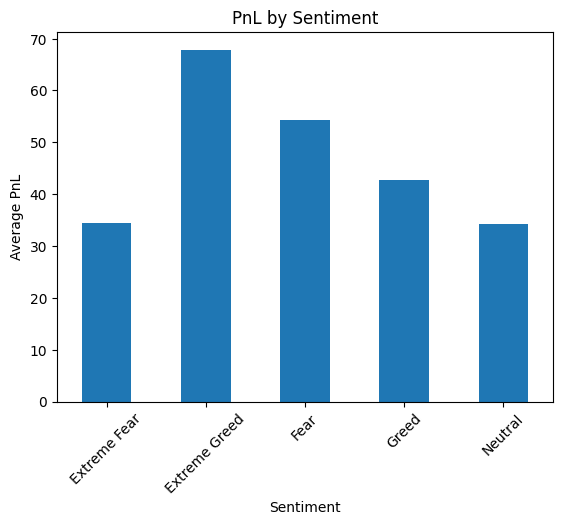

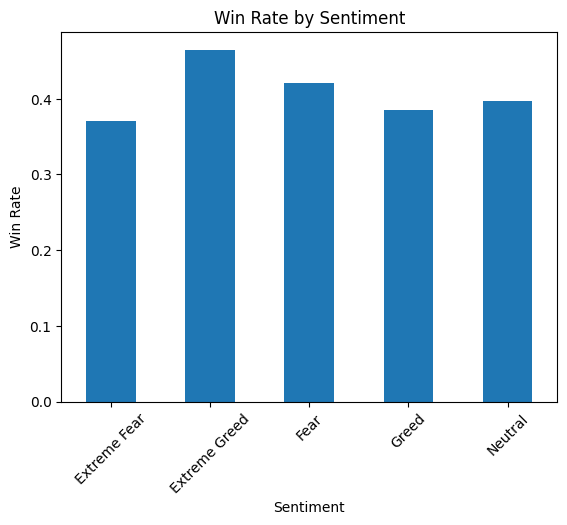

In [17]:
import matplotlib.pyplot as plt

# PnL comparison
pnl_by_sentiment.plot(kind='bar')
plt.title("PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.show()

# Win rate
winrate_by_sentiment.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()